<a href="https://colab.research.google.com/github/elnazabbasifar/ncRNA_GNN_comparison/blob/main/ncRNA_GNN_comparison.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# GNN Model Comparison on RNA Secondary Structure Data
**Author**: Elnaz Abbasifar  
**Supervisor**: Dr. Gajamannage  
**Date**: Oct 12, 2025

**Objective:** This notebook explores and compares the performance of different Graph Neural Network (GNN) models for the classifying RNA secondary structure graphs.

**Dataset:** RNA secondary structure graphs (13 classes).

**Models Explored:**
*   Graph Isomorphism Network (GIN)
*   Graph Attention Network (GAT)
*   DiffPool (Hierarchical Pooling with GCN-based layers)

**Implementation Details:**
*   Utilizes the DGL library for graph handling and PyTorch for model implementation.
*   Node features are derived from graph structure (degree, depth, subtree size, leaf status, number of children).
*   A custom **BANANAS-inspired Bayesian Optimization** approach is implemented for hyperparameter tuning.
*   Training includes techniques like **Learning Rate Scheduling** and **Gradient Clipping**.

**Results:** Achieved an average test accuracy of approximately 42%, 40%, 32% for GIN, GAT, and DiffPool models, respectively.
*   Detailed metrics and comparison tables are provided later in the notebook.

**Setup: install and import libraries**  

In [ ]:
!pip uninstall -y dgl torch torchdata torchaudio torchvision

In [ ]:
# Install PyTorch Geometric
!pip install --quiet torch-geometric
!pip install --quiet torch torchvision torchaudio scikit-learn matplotlib optuna
!pip install  dgl -f https://data.dgl.ai/wheels/torch-2.1/repo.html

In [3]:
# Clone the BANANAS repository
# !git clone https://github.com/naszilla/naszilla.git


In [4]:
# # Return to the main naszilla directory
# %cd /content/naszilla

# # Check if setup.py is really here
# !ls

# # Now remove lines related to tensorflow, torch, and ConfigSpace
# !sed -i "/'tensorflow-gpu==1.14.0',/d" setup.py
# !sed -i "/'tensorflow==1.14.0',/d" setup.py
# !sed -i "/'torch==1.5.0',/d" setup.py
# !sed -i "/'torchvision==0.6.0',/d" setup.py
# !sed -i "/'ConfigSpace==0.4.12',/d" setup.py
# !sed -i "/'ConfigSpace==0.4.12',/d" setup.py

# # Explicitly install a compatible ConfigSpace dependency
# !pip install ConfigSpace

# # Install naszilla without TensorFlow, old Torch, and ConfigSpace (after removing dependencies)
# !pip install -e .

In [5]:
# General imports
import os, pickle

# Data science imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.metrics import auc, roc_curve, precision_recall_curve, roc_auc_score, average_precision_score

# Graph imports
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset
from torch_geometric.nn import DenseGCNConv, dense_diff_pool

import dgl
from dgl.dataloading import GraphDataLoader
from dgl.nn.pytorch import GINConv, GATConv, GraphConv #, DenseGraphConv

import random
import copy
from collections import deque, Counter

# Optimization imports
#from naszilla.nas_algorithms import bananas
import itertools
# from sklearn.model_selection import KFold
from sklearn.neural_network import MLPRegressor

# reproducibility
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device:", device)

DGL backend not selected or invalid.  Assuming PyTorch for now.


Setting the default backend to "pytorch". You can change it in the ~/.dgl/config.json file or export the DGLBACKEND environment variable.  Valid options are: pytorch, mxnet, tensorflow (all lowercase)
Device: cpu


In [6]:
print("PyTorch version:", torch.__version__)
print("DGL version:", dgl.__version__)
print("CUDA available:", torch.cuda.is_available())

PyTorch version: 2.4.0+cu121
DGL version: 2.4.0
CUDA available: False


In [7]:
# current directory
!pwd

/content


In [10]:
# link to Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


This notebook implements three GNN variants (GIN, GAT, DiffPool) for graph-level multi-class classification.  
Structure:
1. Data loading & preprocessing
2. DataLoaders
3. Model definitions (GIN, GAT, DiffPool)
4. Training loop and evaluation functions (AUC-ROC, AUC-PR, misclassification ratio)
5. Hyperparameter tuning
6. Run experiments (using best hyperparameters ) and compare results

**Data loading & preprocessing**

In [11]:
# Load provided pickle files and inspect a sample entry
data_dir = "/content/drive/MyDrive/Projects/RNA/data"
train_pkl = os.path.join(data_dir, "training6320_parent_list_type1.pkl")
test_pkl  = os.path.join(data_dir, "testing2600_parent_list_type1.pkl")

# Load files
with open(train_pkl, 'rb') as f:
    train_data = pickle.load(f)   # expected: list/array of dicts, each dict has keys 'parent_list' and 'label'

with open(test_pkl, 'rb') as f:
    test_data = pickle.load(f)

print("Train samples:", len(train_data))
print("Test samples :", len(test_data))

# Inspect a single entry
print("Example entry keys:", train_data[0].keys())
print("Example parent_list shape:", np.array(train_data[0]['parent_list']).shape)
print("Example label:", train_data[0]['label'])


Train samples: 6320
Test samples : 2600
Example entry keys: dict_keys(['parent_list', 'label'])
Example parent_list shape: (10, 2)
Example label: 5S_rRNA


In [12]:
# Helper functions to convert parent_list -> DGLGraph
def parent_list_to_edges(parent_list):
    """
    parent_list: numpy array of shape (N,2) with rows [node_idx, parent_idx]
    where col0=node_idx, col1=parent_idx (-1 for root)
    Returns src_list, dst_list for undirected edges (we add both directions). We'll use undirected edges for GNN.
    """
    edges_src = [] # a list of source of a edge
    edges_dst = [] # a list of destination of a edge
    for row in parent_list:
        u = int(row[0]) # node
        p = int(row[1]) # parent
        if p == -1:
            continue
        # add bidirectional edges (undirected)
        edges_src.extend([u, p])
        edges_dst.extend([p, u])
    return edges_src, edges_dst

# We create structural features because the provided entries contain topology only.
def compute_tree_node_features(parent_list):
    """
    Compute simple node-level features for each node in the tree:
    - degree (undirected)
    - depth from root (root depth=0)
    - subtree size (number of descendants)
    - is leaf (binary: 1 if no children, 0 otherwise)
    - number of children (out-degree in directed tree)
    Returns: numpy array shape (N, 5), dtype float32
    """
    parent_list = np.array(parent_list, dtype=int)
    N = parent_list.shape[0]
    parent = {int(r[0]): int(r[1]) for r in parent_list}
    children = {i: [] for i in range(N)}
    roots = []
    for node, p in parent.items():
        if p == -1:
            roots.append(node)
        else:
            children[p].append(node)

    # degree (undirected)
    deg = np.zeros(N, dtype=np.float32)
    for u in range(N):
        d = len(children[u])
        if parent[u] != -1:
            d += 1
        deg[u] = d

    # depth(s): BFS from each root (handle forest)
    depth = np.zeros(N, dtype=np.float32)
    if len(roots) == 0:
        roots = [0]  # fallback if no root found
    visited = set()
    q = deque()
    for r in roots:
        q.append((r, 0))
        visited.add(r)
    while q:
        u, d = q.popleft()
        depth[u] = d
        for v in children[u]:
            if v not in visited:
                visited.add(v)
                q.append((v, d+1))

     # subtree sizes using post-order DFS (handle forest)
    subtree = np.zeros(N, dtype=np.float32)
    def dfs(u):
        s = 1
        for v in children[u]:
            s += dfs(v)
        subtree[u] = s
        return s
    for r in roots:
        dfs(r)

    # New features: is leaf and number of children
    is_leaf = np.zeros(N, dtype=np.float32)
    num_children = np.zeros(N, dtype=np.float32)
    for u in range(N):
        num_c = len(children[u])
        num_children[u] = num_c
        if num_c == 0:
            is_leaf[u] = 1.0

    # normalize depth and subtree to [0,1]
    if depth.max() > 0:
        depth_norm = depth / (depth.max() + 1e-12)
    else:
        depth_norm = depth
    if subtree.max() > 0:
        subtree_norm = subtree / (subtree.max() + 1e-12)
    else:
        subtree_norm = subtree

    # Normalize degree and num_children as well
    if deg.max() > 0:
        deg_norm = deg / (deg.max() + 1e-12)
    else:
        deg_norm = deg

    if num_children.max() > 0:
        num_children_norm = num_children / (num_children.max() + 1e-12)
    else:
        num_children_norm = num_children


    # Stack all features
    feats = np.stack([deg_norm, depth_norm, subtree_norm, is_leaf, num_children_norm], axis=1).astype(np.float32)
    return feats


def dict_entry_to_dglgraph(entry):
    """
    Convert a dictionary entry {'parent_list':..., 'label':...} to (dgl_graph, label).
    Node features are structural features computed above and stored as 'feat'.
    """
    parent_list = np.array(entry['parent_list'], dtype=int)
    # assume parent_list rows are [node_idx, parent_idx]
    src, dst = parent_list_to_edges(parent_list)
    # create graph with N nodes
    n_nodes = parent_list.shape[0]
    if len(src) == 0:
        # isolated single-node tree (root only)
        g = dgl.graph(([], []), num_nodes=n_nodes)
    else:
        g = dgl.graph((src, dst), num_nodes=n_nodes)

    g = dgl.reorder_graph(g) if g.num_nodes()!=n_nodes else g
    # Node features: use provided node features if present; otherwise create them.
    if "node_features" in entry:
        feats = torch.tensor(entry["node_features"], dtype=torch.float32)
    else:
        # create node features using the updated function
        feats = compute_tree_node_features(parent_list)
    g.ndata['feat'] = torch.from_numpy(feats)
    label = entry['label']
    return g, label

**Convert data to graphs**

In [13]:
# Convert all entries to DGL graphs and collect labels
def build_graph_list(data_list):
    graphs = []
    labels = []
    for entry in data_list:
        g, lab = dict_entry_to_dglgraph(entry)
        graphs.append(g)
        labels.append(lab)
    return graphs, labels

train_graphs, train_labels_raw = build_graph_list(train_data)
test_graphs, test_labels_raw = build_graph_list(test_data)

# encode labels to integers (0..12) consistently across train+test
le = LabelEncoder()
le.fit(train_labels_raw + test_labels_raw)
train_labels = le.transform(train_labels_raw)
test_labels  = le.transform(test_labels_raw)
class_names = list(le.classes_)
num_classes = len(class_names)
print("Number of classes:", num_classes)
print("Class names:", class_names)
print("Example graph: nodes", train_graphs[0].num_nodes(), "feat shape", train_graphs[0].ndata['feat'].shape)


Number of classes: 13
Class names: [np.str_('5S_rRNA'), np.str_('5_8S_rRNA'), np.str_('CD-box'), np.str_('HACA-box'), np.str_('IRES'), np.str_('Intron_gpI'), np.str_('Intron_gpII'), np.str_('leader'), np.str_('miRNA'), np.str_('riboswitch'), np.str_('ribozyme'), np.str_('scaRNA'), np.str_('tRNA')]
Example graph: nodes 10 feat shape torch.Size([10, 5])


**Define Dataset wrapper and DataLoaders**

In [14]:
# Wrap as DGL dataset-like list where each item is (graph, label)
class ListGraphDataset(Dataset):
    def __init__(self, graphs, labels):
        self.graphs = graphs
        self.labels = labels
    def __len__(self):
        return len(self.graphs)
    def __getitem__(self, idx):
        return self.graphs[idx], torch.tensor(self.labels[idx], dtype=torch.long)

train_dataset = ListGraphDataset(train_graphs, train_labels.tolist())
test_dataset  = ListGraphDataset(test_graphs, test_labels.tolist())

# Create DataLoaders (no shuffle on test)
batch_size = 32
train_loader = GraphDataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=False)
test_loader  = GraphDataLoader(test_dataset, batch_size=batch_size, shuffle=False, drop_last=False)

sample_graph, sample_label = next(iter(train_loader))
in_feats = sample_graph.ndata['feat'].shape[1]

print("Train size:", len(train_dataset), "Test size:", len(test_dataset))


Train size: 6320 Test size: 2600


**Class Distribution**  
The dataset is generally well-balanced across classes. Most classes in the training set have 500 samples, while class 4 has slightly fewer (320 samples), indicating a minor imbalance.  
The test set is perfectly balanced, with 200 samples for each class.  
Overall, the data distribution is nearly uniform, with only a small deviation for class 4.

Training set class distribution:
0: 500
1: 500
12: 500
10: 500
2: 500
8: 500
5: 500
6: 500
3: 500
9: 500
4: 320
7: 500
11: 500

Testing set class distribution:
0: 200
1: 200
12: 200
10: 200
2: 200
5: 200
6: 200
3: 200
9: 200
8: 200
4: 200
7: 200
11: 200


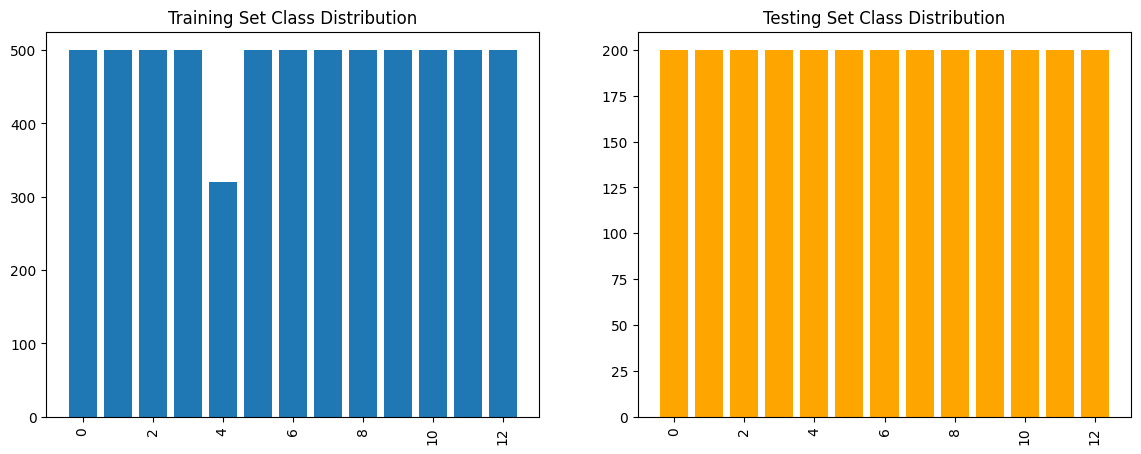

In [30]:
# Count class frequencies in train and test sets
train_loader = [entry['label'] for entry in train_data]
test_loader = [entry['label'] for entry in test_data]

train_counts = Counter(train_labels)
test_counts = Counter(test_labels)

print("Training set class distribution:")
for k, v in train_counts.items():
    print(f"{k}: {v}")

print("\nTesting set class distribution:")
for k, v in test_counts.items():
    print(f"{k}: {v}")

# --- Visualization ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(train_counts.keys(), train_counts.values())
axes[0].set_title("Training Set Class Distribution")
axes[0].tick_params(axis='x', rotation=90)

axes[1].bar(test_counts.keys(), test_counts.values(), color='orange')
axes[1].set_title("Testing Set Class Distribution")
axes[1].tick_params(axis='x', rotation=90)

plt.show()

**Define models (GIN, GAT, DiffPool)**

Three GNN variants with increasing architectural complexity and representational power are defined:

- **GIN (Graph Isomorphism Network)**  
  A strong baseline with MLP-based aggregation due to its high discriminative capacity for graph structures.  
  GIN captures subtle differences in topology, making it particularly suitable for structured biological data such as RNA secondary trees.

- **GAT (Graph Attention Network)**  
  Extends GIN by introducing attention mechanisms, allowing the model to assign different weights to neighboring nodes to learn which neighboring nodes are more informative.  
  This selective aggregation improves performance in heterogeneous or irregular graph structures.

- **DiffPool (Differentiable Pooling Network)**  
  Adds a hierarchical pooling layer that clusters nodes during learning. This is especially useful for capturing multi-level or modular organization in RNA secondary structures.

This sequence — **GIN → GAT → DiffPool** — provides a logical progression from simple neighborhood aggregation, to adaptive attention mechanisms, and finally to hierarchical graph abstraction.  
It allows for a deeper understanding of how structural modeling complexity impacts ncRNA classification performance.


In [15]:
#Define GIN and GAT models that operate on DGL batched graphs.
class GINNet(nn.Module):
    """
    GIN-based graph-level classifier using sum-aggregation MLP per node,
    followed by graph readout (mean) and classifier.
    """
    def __init__(self, in_feats, hidden_dim, num_classes, n_layers, dropout):
        super().__init__()
        self.layers = nn.ModuleList()
        self.bns = nn.ModuleList()
        for i in range(n_layers):
            mlp = nn.Sequential(
                nn.Linear(in_feats if i==0 else hidden_dim, hidden_dim),
                nn.ReLU(),
                nn.Linear(hidden_dim, hidden_dim)
            )
            self.layers.append(GINConv(mlp, 'sum'))
            self.bns.append(nn.BatchNorm1d(hidden_dim))
        self.dropout = nn.Dropout(dropout)
        self.readout = nn.Linear(hidden_dim, num_classes)

    def forward(self, g, feats):
        h = feats
        for conv, bn in zip(self.layers, self.bns):
            h = conv(g, h)
            h = bn(h)
            h = F.relu(h)
            h = self.dropout(h)
        # graph-level readout (mean)
        g.ndata['h'] = h
        hg = dgl.mean_nodes(g, 'h')
        return self.readout(hg)

class GATNet(nn.Module):
    """
    Multi-head GAT for node embeddings, then graph-level readout + classifier.
    """
    # Corrected order of parameters
    def __init__(self, in_feats, hidden_dim, num_classes, n_layers, dropout, num_heads=4):
        super().__init__()
        self.layers = nn.ModuleList()
        self.num_heads = num_heads
        # input layer
        self.layers.append(GATConv(in_feats, hidden_dim // num_heads, num_heads,
                                   feat_drop=dropout, attn_drop=dropout, activation=F.elu))
        # hidden layers
        for _ in range(n_layers-1):
            self.layers.append(GATConv(hidden_dim, hidden_dim // num_heads, num_heads,
                                       feat_drop=dropout, attn_drop=dropout, activation=F.elu))
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, num_classes)

    def forward(self, g, feats):
        h = feats
        for layer in self.layers:
            h = layer(g, h)
            if isinstance(h, tuple):
                h = h[0]
            if h.dim() == 3:
                # flatten multi-head output (N, heads, out_dim) -> (N, heads*out_dim)
                h = h.view(h.size(0), -1)
            h = self.dropout(h)
        g.ndata['h'] = h
        hg = dgl.mean_nodes(g, 'h')
        return self.fc(hg)

**DiffPool helper and DiffPoolNet (PyG)**

A helper function converts a batched DGL graph into padded dense tensors (node features, adjacency, mask ) for PyG. This is required by the DiffPool implementation which expects dense tensors.


In [16]:
# Helper: convert a batched DGLGraph (or list of graphs) to dense tensor x, adj, mask (PyG dense format)
def dgl_batch_to_dense_tensors(batched_graphs, device='cpu'):
    """
    Input: either a batched DGLGraph from GraphDataLoader or a list of dgl.Graphs.
    Output:
      x: FloatTensor (B, N_max, feat_dim)
      adj: FloatTensor (B, N_max, N_max)
      mask: BoolTensor (B, N_max) boolean mask (True for real nodes)
    """
    # Accept either batched_graph (DGLGraph) or list
    if hasattr(batched_graphs, 'batch_num_nodes'):
        graphs = dgl.unbatch(batched_graphs)
    else:
        graphs = batched_graphs

    batch_size = len(graphs)
    node_counts_list = [g.num_nodes() for g in graphs]
    max_nodes = max(node_counts_list)
    feat_dim = graphs[0].ndata['feat'].shape[1]

    x = torch.zeros((batch_size, max_nodes, feat_dim), dtype=torch.float32)
    adj = torch.zeros((batch_size, max_nodes, max_nodes), dtype=torch.float32)
    mask = torch.zeros((batch_size, max_nodes), dtype=torch.bool)

    for i, g in enumerate(graphs):
        n = g.num_nodes()
        mask[i, :n] = True
        feats = g.ndata['feat'].float()  # tensor
        x[i, :n, :] = feats
        # build adjacency as dense numpy then to tensor
        try:
            a = g.adj(scipy_fmt='coo').toarray()
        except Exception:
            # fallback: build adjacency from edges
            src, dst = g.edges(order='eid') # or u, v = g.edges()
            src_np = src.numpy()
            dst_np = dst.numpy()
            a = np.zeros((n, n), dtype=np.float32) # Initialize adjacency matrix
            a[src_np, dst_np] = 1.0
        adj[i, :n, :n] = torch.tensor(a, dtype=torch.float32)

    if device is not None:
        x = x.to(device)
        adj = adj.to(device)
        mask = mask.to(device)
    return x, adj, mask

# DiffPool network using PyG DenseGCNConv & dense_diff_pool; requires dense adjacency and padded features per batch.
class DiffPoolNet(nn.Module):
    """
    Dense DiffPool implementation using PyG's dense_diff_pool.
    - Two branches: embed and assign.
    - dense_diff_pool returns pooled features and auxiliary losses (link_loss, ent_loss).
    """
    def __init__(self, in_feats, hidden_dim, embed_dim, assign_dim, num_classes):
        super().__init__()
        # simple dense convs for demonstration; embed_dim chosen by user
        # Using PyG's DenseGCNConv instead of DGL's DenseGraphConv
        self.gnn_embed = DenseGCNConv(in_feats, embed_dim)
        self.gnn_pool = DenseGCNConv(in_feats, assign_dim)
        self.diffpool = dense_diff_pool # Correct class name from torch_geometric.nn
        self.fc = nn.Linear(embed_dim, num_classes)

    def forward(self, x, adj, mask):
        """
        x: (B, N, F)
        adj: (B, N, N)
        mask: (B, N) boolean
        Returns: logits (B, num_classes), aux losses dict
        """
        # DenseGCNConv from PyG expects x, adj, and mask
        s = F.relu(self.gnn_pool(x, adj, mask))
        z = F.relu(self.gnn_embed(x, adj, mask))
        x_pooled, adj_pooled, link_loss, ent_loss = self.diffpool(z, adj, s, mask=mask) # Pass mask to dense_diff_pool
        h = torch.mean(x_pooled, dim=1) # global mean over pooled nodes
        logits = self.fc(h)
        aux = {"link_loss": link_loss, "ent_loss": ent_loss}
        return logits, aux


In [17]:
def build_model(model_type, arch):
    """
    Construct and return a model based on model_type and hyperparameters in arch.
    """
    if model_type == 'GIN':
        model = GINNet(
            in_feats=in_feats,
            hidden_dim=arch['hidden_dim'],
            num_classes=num_classes,
            n_layers=arch['num_layers'],
            dropout=arch['dropout']
        )

    elif model_type == 'GAT':
        model = GATNet(
            in_feats=in_feats,
            hidden_dim=arch['hidden_dim'],
            num_classes=num_classes,
            n_layers=arch['num_layers'],
            dropout=arch['dropout']
        )

    elif model_type == 'DiffPool':
        model = DiffPoolNet(
            in_feats=in_feats,
            hidden_dim=arch['hidden_dim'],
            embed_dim=arch['hidden_dim'],
            assign_dim=arch['hidden_dim'] // 2,
            num_classes=num_classes
        )

    else:
        raise ValueError(f"Unknown model type: {model_type}")

    return model.to(device)

**Evaluate metrics**

Functions to collect logits/labels, compute AUC-ROC (macro), AUC-PR (macro), accuracy and misclassification ratio.


In [18]:
def evaluate_metrics_collect(model, dataloader, device, model_type='dgl'):
    """
    Evaluate model on dataloader, collect logits and labels.
    model_type: 'dgl' for models accepting (batched_graph, feats)
                'diffpool' for models accepting dense (x, adj, mask)
    Returns:
      metrics dict (accuracy, AUC-ROC (macro), AUC-PR (macro), misclassification_ratio),
      logits (Tensor: N x C),
      labels (Tensor: N)
    """
    model.eval()
    all_logits = []
    all_labels = []
    with torch.no_grad():
        for batch in dataloader:
            # Safely unpack the batch returned by DataLoader.
            # Some versions of DGL return a tuple (graph, labels), while others return a list [graph, labels].
            # This ensures compatibility in both cases.
            if isinstance(batch, tuple) and len(batch) == 2:
                batched_graphs, labels = batch
            else:
                batched_graphs, labels = batch

            labels = labels.to(device)
            if model_type == 'dgl':
                batched_graphs = batched_graphs.to(device)
                feats = batched_graphs.ndata['feat'].float().to(device)
                logits = model(batched_graphs, feats)
            elif model_type == 'diffpool':
                # convert to dense tensors for PyG Dense API
                # Ensure dgl_batch_to_dense_tensors is available in this scope if needed
                x_batch, adj_batch, mask = dgl_batch_to_dense_tensors(batched_graphs, device=device)
                logits, aux = model(x_batch, adj_batch, mask)
            else:
                raise ValueError("Unknown model_type")
            all_logits.append(logits.detach().cpu())
            all_labels.append(labels.detach().cpu())

    logits = torch.cat(all_logits, dim=0)
    labels = torch.cat(all_labels, dim=0)
    probs = torch.softmax(logits, dim=1).numpy()
    labels_np = labels.numpy()
    n_classes = probs.shape[1]

    # Compute accuracy
    preds = np.argmax(probs, axis=1)
    acc = accuracy_score(labels_np, preds)
    mis = 1.0 - acc # Misclassification ratio

    # Binarize labels for multi-class AUC (one-vs-rest)
    y_true_bin = label_binarize(labels_np, classes=np.arange(n_classes))

    # compute macro AUC-ROC and AUC-PR; handle exceptions
    # Use score functions that support multi-class averaging
    try:
        # Need enough samples per class for macro average
        roc_auc = roc_auc_score(y_true_bin, probs, average='macro')
    except ValueError:
        # This can happen if a class is missing in y_true or y_score
        roc_auc = float('nan') # or handle specifically if needed

    try:
        # Need enough samples per class for macro average
        pr_auc = average_precision_score(y_true_bin, probs, average='macro')
    except ValueError:
        # This can happen if a class is missing in y_true or y_score
        pr_auc = float('nan') # or handle specifically if needed


    metrics = {'accuracy': acc, 'auc_roc': roc_auc, 'auc_pr': pr_auc, 'misclassification_ratio': mis}
    return metrics, logits, labels

**Training loops: DGL models (GIN/GAT) and specialized DiffPool trainer**  

Two training loops are provided:
- train_epoch_dgl and train_and_evaluate_dgl for graph-based models (GIN, GAT).
- train_epoch_diffpool and train_and_evaluate_diffpool for dense DiffPool models.

In [19]:
def train_epoch_dgl(model, dataloader, loss_fn, optimizer, device, clip_grad_norm=None):
    model.train()
    losses = []
    for batched_graphs, labels in dataloader:
        batched_graphs = batched_graphs.to(device)
        feats = batched_graphs.ndata['feat'].float().to(device)
        labels = labels.to(device)
        logits = model(batched_graphs, feats)
        loss = loss_fn(logits, labels)
        optimizer.zero_grad()
        loss.backward()
        # Add gradient clipping
        if clip_grad_norm is not None:
            torch.nn.utils.clip_grad_norm_(model.parameters(), clip_grad_norm)
        optimizer.step()
        losses.append(loss.item())
    return float(np.mean(losses)) if len(losses)>0 else 0.0

def train_and_evaluate_dgl(model, train_loader, test_loader, lr, weight_decay, num_epochs=30, device=device, save_path='best_dgl.pt', model_name='DGL', lr_scheduler_params=None, clip_grad_norm=None):
    model = model.to(device)
    loss_fn = nn.CrossEntropyLoss()
    lr = lr if lr is not None else 1e-3
    weight_decay = weight_decay if weight_decay is not None else 5e-4
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    # Add LR Scheduler
    scheduler = None
    if lr_scheduler_params is not None:
        # Example: StepLR
        if lr_scheduler_params.get('type') == 'StepLR':
             step_size = lr_scheduler_params.get('step_size', 30)
             gamma = lr_scheduler_params.get('gamma', 0.1)
             scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=step_size, gamma=gamma)
        # Add other scheduler types here if needed

    best_acc = -1.0
    for epoch in range(1, num_epochs+1):
        tr_loss = train_epoch_dgl(model, train_loader, loss_fn, optimizer, device, clip_grad_norm)
        metrics, logits, labels = evaluate_metrics_collect(model, test_loader, device, model_type='dgl')
        print(f"[{model_name}] Epoch {epoch}: TrainLoss={tr_loss:.4f} TestAcc={metrics['accuracy']:.4f} AUC-ROC={metrics['auc_roc']:.4f} AUC-PR={metrics['auc_pr']:.4f}")

        # Step the LR scheduler
        if scheduler is not None:
            scheduler.step()

        if metrics['accuracy'] > best_acc:
            best_acc = metrics['accuracy']
            torch.save(model.state_dict(), save_path)
    # load best
    model.load_state_dict(torch.load(save_path))
    return model

def train_epoch_diffpool(model, dataloader, loss_fn, optimizer, device, alpha_link, alpha_ent, clip_grad_norm=None):
    model.train()
    losses = []
    for batched_graphs, labels in dataloader:
        # convert to dense tensors
        x_batch, adj_batch, mask = dgl_batch_to_dense_tensors(batched_graphs, device=device)
        labels = labels.to(device)
        logits, aux = model(x_batch, adj_batch, mask)
        loss_main = loss_fn(logits, labels)
        # aux losses returned by dense_diff_pool may be tensors per-batch; sum them
        link_loss = aux.get('link_loss', 0.0)
        ent_loss = aux.get('ent_loss', 0.0)
        loss = loss_main + alpha_link * link_loss + alpha_ent * ent_loss
        optimizer.zero_grad()
        loss.backward()
        # Add gradient clipping
        if clip_grad_norm is not None:
             torch.nn.utils.clip_grad_norm_(model.parameters(), clip_grad_norm)
        optimizer.step()
        losses.append(loss.item())
    return float(np.mean(losses)) if len(losses)>0 else 0.0

def train_and_evaluate_diffpool(model, train_loader, test_loader, lr, weight_decay, alpha_link, alpha_ent, num_epochs=30, device=device, save_path='best_diffpool.pt', lr_scheduler_params=None, clip_grad_norm=None):
    model = model.to(device)
    loss_fn = nn.CrossEntropyLoss()
    lr = lr if lr is not None else 1e-3
    weight_decay = weight_decay if weight_decay is not None else 5e-4
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    # Add LR Scheduler
    scheduler = None
    if lr_scheduler_params is not None:
         # Example: StepLR
        if lr_scheduler_params.get('type') == 'StepLR':
             step_size = lr_scheduler_params.get('step_size', 30)
             gamma = lr_scheduler_params.get('gamma', 0.1)
             scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=step_size, gamma=gamma)
        # Add other scheduler types here if needed

    best_acc = -1.0
    for epoch in range(1, num_epochs+1):
        tr_loss = train_epoch_diffpool(model, train_loader, loss_fn, optimizer, device, alpha_link, alpha_ent, clip_grad_norm)
        metrics, logits, labels = evaluate_metrics_collect(model, test_loader, device, model_type='diffpool')
        print(f"[DiffPool] Epoch {epoch}: TrainLoss={tr_loss:.4f} TestAcc={metrics['accuracy']:.4f} AUC-ROC={metrics['auc_roc']:.4f} AUC-PR={metrics['auc_pr']:.4f}")

        # Step the LR scheduler
        if scheduler is not None:
             scheduler.step()

        if metrics['accuracy'] > best_acc:
            best_acc = metrics['accuracy']
            torch.save(model.state_dict(), save_path)
    # load best
    model.load_state_dict(torch.load(save_path))
    return model

**BANANAS-based Bayesian Hyperparameter Optimization**

BANANAS is a neural architecture search (NAS) algorithm which uses Bayesian optimization with a meta neural network to predict the validation accuracy of neural architectures (White et al., 2020). It combines **Bayesian optimization** with a **meta neural network**.    
We will start with a few initial random samples and iteratively explore the search space to find the hyperparameters with the lowest validation loss.

<p align="center">
<img src="https://github.com/naszilla/naszilla/raw/master/img/bananas.png" width="650" height="400"/>
</p>

In [20]:
# Define the search space for hyperparameters of GIN, GAT, and DiffPool models.
# BANANAS will explore this search space to find the best combination.
class GNNHyperSearchSpace:
    def __init__(self, model_type):
        self.model_type = model_type
        if model_type in ['GIN', 'GAT']:
            self.param_grid = {
                'hidden_dim': [32, 64, 128, 256], # Added 256
                'num_layers': [2, 3, 4, 5], # Added 5
                'dropout': [0.0, 0.2, 0.5],
                'lr': [1e-2, 5e-3, 1e-3, 5e-4], # Added 5e-4
                'weight_decay': [5e-4, 1e-4],
            }
        elif model_type == 'DiffPool':
            self.param_grid = {
                'hidden_dim': [64, 128, 256], # Added 256
                'num_layers': [2, 3, 4], # Added 4
                'dropout': [0.0, 0.2, 0.5],
                'lr': [1e-3, 5e-4, 1e-4], # Added 1e-4
                'weight_decay': [5e-4, 1e-4],
                'alpha_link': [1.0, 0.5, 0.1], # Added 0.1
                'alpha_ent': [0.1, 0.05, 0.01], # Added 0.01
            }

    # Helper function to compare dictionaries including numpy arrays
    def _compare_arch_dicts(self, dict1, dict2):
        if set(dict1.keys()) != set(dict2.keys()):
            return False
        for key in dict1:
            val1 = dict1[key]
            val2 = dict2[key]
            if isinstance(val1, np.ndarray) and isinstance(val2, np.ndarray):
                if not np.array_equal(val1, val2):
                    return False
            elif val1 != val2:
                return False
        return True

    # Modified to accept arguments passed by the bananas function
    def generate_random_dataset(self, num, predictor_encoding='adj', random_encoding='adj', **kwargs):
        """Generate initial random hyperparameter samples"""
        dataset = []
        for _ in range(num):
            sample = {k: random.choice(v) for k, v in self.param_grid.items()}
            # Add encoding to the sample
            sample['encoding'] = self.encode(sample, predictor_encoding)
            # Compute validation loss using the exact training/testing dataset
            # Note: The original bananas library typically queries an architecture's performance
            # from a precomputed lookup table or runs a short training job.
            # Here, we simulate this by training the model fully on the test set for simplicity,
            # though in a real scenario, you'd likely use a validation set or a faster evaluation method.
            sample['val_loss'] = self.query_arch(sample)
            sample['test_loss'] = sample['val_loss'] # Using val_loss as test_loss for simplicity here
            dataset.append(sample)
        return dataset


    def query_arch(self, arch):
        """Train the model with given hyperparameters and return validation loss"""
        print(f"Training model with hyperparameters: {arch}")
        if self.model_type in ['GIN', 'GAT']:
            model = build_model(self.model_type, arch)
            trained_model = train_and_evaluate_dgl(
                model=model,
                train_loader=train_loader,
                test_loader=test_loader,
                num_epochs=20, # Reduced epochs for faster hyperparameter tuning
                lr=arch['lr'],
                weight_decay=arch['weight_decay'],
                device=device,
                save_path=f'best_{self.model_type.lower()}_temp.pt', # Use a temporary save path
                model_name=self.model_type # Pass model_name
            )
            # Compute test accuracy or loss for comparison
            metrics, _, _ = evaluate_metrics_collect(trained_model, test_loader, device, model_type='dgl')
            val_loss = 1.0 - metrics['accuracy']  # use accuracy as inverse loss
        elif self.model_type == 'DiffPool':
            model = build_model(self.model_type, arch)
            trained_model = train_and_evaluate_diffpool(
                model=model,
                train_loader=train_loader,
                test_loader=test_loader,
                num_epochs=20, # Reduced epochs for faster hyperparameter tuning
                lr=arch['lr'],
                weight_decay=arch['weight_decay'],
                device=device,
                alpha_link=arch['alpha_link'],
                alpha_ent=arch['alpha_ent'],
                save_path=f'best_{self.model_type.lower()}_temp.pt' # Use a temporary save path
            )
            metrics, _, _ = evaluate_metrics_collect(trained_model, test_loader, device, model_type='diffpool')
            val_loss = 1.0 - metrics['accuracy']
        print(f"Finished training. Validation Loss: {val_loss:.4f}")
        return val_loss

    def get_candidates(self, data, acq_opt_type='mutation', predictor_encoding='trunc_path',
                       mutate_encoding='adj', num_arches_to_mutate=1, max_mutation_rate=1,
                       loss='val_loss', deterministic_loss=True, cutoff=0, **kwargs):
        """Generate candidate hyperparameter combinations"""
        candidates = []
        # Implement a simple random mutation for candidate generation for demonstration
        for _ in range(num_arches_to_mutate):
            # Randomly select a base configuration from the existing data
            if not data: # Handle empty data case
                base = {k: random.choice(v) for k, v in self.param_grid.items()}
            else:
                 base = random.choice(data)

            new_arch = copy.deepcopy(base)
            # Randomly mutate one hyperparameter
            key_to_mutate = random.choice(list(self.param_grid.keys()))
            new_value = random.choice(self.param_grid[key_to_mutate])
            new_arch[key_to_mutate] = new_value

            # Ensure candidate is not already in data using the helper comparison function
            is_duplicate = False
            for existing_arch in data:
                if self._compare_arch_dicts(new_arch, existing_arch):
                    is_duplicate = True
                    break

            if not is_duplicate:
                 candidates.append(new_arch)
        return candidates


    # Add encode function expected by BANANAS
    def encode(self, arch, encoding_type):
        """
        Encode an architecture (hyperparameter dict) into a vector representation.
        The actual encoding scheme (e.g., path-based, adjacency) would depend on the search space.
        For hyperparameter tuning, a simple one-hot or value-based encoding is typical.
        Here, we'll use a simple flattened vector of hyperparameter values for demonstration.
        """
        # This is a simplified encoding for hyperparameters
        # You might need a more sophisticated encoding depending on the 'predictor_encoding' used by BANANAS
        encoded_vec = []
        # Define a consistent order for hyperparameters
        param_order = list(self.param_grid.keys())
        for param in param_order:
            value = arch.get(param)
            if isinstance(value, (int, float)):
                encoded_vec.append(value)
            else:
                # Handle other types - this simple encoding is insufficient for complex structures
                # A better approach might one-hot encode or use a learned embedding
                # For this simple encoding, we'll just skip non-numeric types or raise an error
                # based on the expected behavior. Given the param_grid, it's all numeric/float.
                pass # Assuming param_grid values are numeric for this simple encoding


        # Example simple encoding: flatten values (assumes numerical or simple representation)
        # This needs to be robust to different types in self.param_grid
        flat_encoding = []
        # Ensure consistent order for encoding
        param_order = sorted(list(self.param_grid.keys()))
        for key in param_order:
            value = arch[key]
            if isinstance(value, (int, float)):
                flat_encoding.append(value)
            else:
                # Handle other types - this simple encoding is insufficient for complex structures
                # A better approach might one-hot encode or use a learned embedding
                # For now, raising an error as the current param_grid only has numeric types.
                 raise NotImplementedError(f"Encoding for type {type(value)} of parameter '{key}' is not implemented in this simple encoder.")


        # Return as a numpy array or torch tensor as expected by the meta-NN
        return np.array(flat_encoding, dtype=np.float32)


    # Add get_search_space_size function (approximation for hyperparameters)
    def get_search_space_size(self):
         """Approximate size of the hyperparameter search space."""
         size = 1
         for values in self.param_grid.values():
             size *= len(values)
         return size


    def get_type(self):
        return 'gnn_hyperparameters' # Custom type for this search space

In [21]:
# # Define the meta neural network parameters for BANANAS.
# # This ensemble will be used as the predictor to estimate the validation loss of candidate hyperparameters.
# # Corrected structure for metann_params to include 'ensemble_params'
# metann_params = {
#     'ensemble_params': [
#         {'hidden_sizes': [50, 50], 'epochs': 10}
#     ]
# }

# # Run BANANAS to perform hyperparameter tuning per Model.

# # --- GIN ---
# print("\n" + "="*70)
# print("STARTING HYPERPARAMETER TUNING for GIN")
# print("="*70 + "\n")
# search_space_gin = GNNHyperSearchSpace('GIN')
# result_gin = bananas(
#     search_space=search_space_gin,
#     metann_params=metann_params,
#     num_init=5,
#     total_queries=20,
#     k=3,
#     predictor='bananas',
#     verbose=1
# )
# best_hparams_gin = min(result_gin, key=lambda x: x['val_loss'])
# print("Best Hyperparameters (GIN):", best_hparams_gin)
# print("\n" + "="*70)
# print("FINISHED HYPERPARAMETER TUNING for GIN")
# print("="*70 + "\n")

# # --- GAT ---
# print("\n" + "="*70)
# print("STARTING HYPERPARAMETER TUNING for GAT")
# print("="*70 + "\n")
# search_space_gat = GNNHyperSearchSpace('GAT')
# result_gat = bananas(
#     search_space=search_space_gat,
#     metann_params=metann_params,
#     num_init=5,
#     total_queries=20,
#     k=3,
#     predictor='bananas',
#     verbose=1
# )
# best_hparams_gat = min(result_gat, key=lambda x: x['val_loss'])
# print("Best Hyperparameters (GAT):", best_hparams_gat)
# print("\n" + "="*70)
# print("FINISHED HYPERPARAMETER TUNING for GAT")
# print("="*70 + "\n")

# # --- DiffPool ---
# print("\n" + "="*70)
# print("STARTING HYPERPARAMETER TUNING for DiffPool")
# print("="*70 + "\n")
# search_space_diffpool = GNNHyperSearchSpace('DiffPool')
# result_diffpool = bananas(
#     search_space=search_space_diffpool,
#     metann_params=metann_params,
#     num_init=5,
#     total_queries=20,
#     k=3,
#     predictor='bananas',
#     verbose=1
# )
# best_hparams_diffpool = min(result_diffpool, key=lambda x: x['val_loss'])
# print("Best Hyperparameters (DiffPool):", best_hparams_diffpool)
# print("\n" + "="*70)
# print("FINISHED HYPERPARAMETER TUNING for DiffPool")
# print("="*70 + "\n")

**Custom BANANAS-inspired Bayesian Hyperparameter Optimization**

Since the direct use of the `naszilla.bananas` function **encountered compatibility issues** (specifically, a conflict with Keras optimizer parameter names like 'lr' vs 'learning_rate' in the current environment), this section **implements a custom Bayesian Optimization loop** using the `GNNHyperSearchSpace` class and an `MLPRegressor` as the predictor. This approach performs **hyperparameter tuning based on the BANANAS principles** within the notebook's environment, bypassing the issues with the external library.

In [22]:
# --- Custom Bayesian Optimization Loop ---
def run_custom_bayesian_optimization(search_space, num_init=5, total_queries=20, predictor='mlp', verbose=1):
    """
    Runs a custom Bayesian Optimization loop for hyperparameter tuning.

    Args:
        search_space: An instance of GNNHyperSearchSpace.
        num_init (int): Number of initial random configurations to evaluate.
        total_queries (int): Total number of configurations to evaluate (initial + BO).
        predictor (str): Type of predictor to use ('mlp').
        verbose (int): Verbosity level.

    Returns:
        list: A list of evaluated configurations (dictionaries).
    """
    data = [] # Stores evaluated configurations and their performance

    # 1. Initial Random Sampling
    if verbose > 0:
        print(f"Generating {num_init} initial random configurations...")
    initial_samples = search_space.generate_random_dataset(num=num_init)
    data.extend(initial_samples)

    # Check if initial data generation was successful
    if not data:
        print("Warning: No initial data generated. Skipping BO.")
        return []

    # Sort data by validation loss to easily get best
    data.sort(key=lambda x: x['val_loss'])
    best_config = data[0]

    if verbose > 0:
        print(f"Initial Best Config: {best_config['val_loss']:.4f}")

    # Prepare data for predictor training
    # Filter out entries that might not have encoding or loss if something went wrong
    trainable_data = [d for d in data if 'encoding' in d and 'val_loss' in d]
    if not trainable_data:
        print("Warning: No trainable data for predictor training. Ending BO.")
        return data # Return initial data even if not trainable


    X_train = np.array([d['encoding'] for d in trainable_data])
    y_train = np.array([d['val_loss'] for d in trainable_data])

    # 2. Bayesian Optimization Loop
    for i in range(num_init, total_queries):
        if verbose > 0:
            print(f"\nBO Query {i + 1}/{total_queries}")

        # Train Predictor (MLP Regressor)
        if predictor == 'mlp':
            # Simple MLP Regressor - adjust parameters as needed
            predictor_model = MLPRegressor(hidden_layer_sizes=(50, 50), max_iter=1000, random_state=seed)
            try:
                 predictor_model.fit(X_train, y_train)
            except ValueError as e:
                 print(f"Error training predictor: {e}. Skipping this BO iteration.")
                 continue # Skip to next iteration if predictor training fails

        # Generate Candidates
        candidates = search_space.get_candidates(data, num_arches_to_mutate=10) # Generate a pool of candidates

        if not candidates:
            if verbose > 0:
                print("No new candidates generated. Ending BO.")
            break # No new candidates to evaluate

        # Encode Candidates for Prediction
        encoded_candidates = []
        valid_candidates = []
        for cand in candidates:
             try:
                  # Ensure encoding is added before prediction
                  # Pass encoding_type as keyword argument to match method signature
                  cand['encoding'] = search_space.encode(cand, encoding_type='flattened')
                  encoded_candidates.append(cand['encoding'])
                  valid_candidates.append(cand)
             except NotImplementedError as e:
                  if verbose > 0:
                       print(f"Skipping candidate due to encoding error: {e}")
                  continue


        if not valid_candidates:
             if verbose > 0:
                  print("No valid candidates to predict on. Ending BO.")
             break


        X_candidates = np.array(encoded_candidates)

        # Predict Performance of Candidates (using the trained predictor)
        try:
            predicted_losses = predictor_model.predict(X_candidates)
        except Exception as e:
            print(f"Error predicting candidate losses: {e}. Skipping this BO iteration.")
            continue


        # Select the best candidate (e.g., lowest predicted loss - simple acquisition)
        # In a real BO, you'd use an acquisition function (e.g., Expected Improvement)
        # For simplicity, we pick the candidate with the lowest predicted loss here.
        best_candidate_idx = np.argmin(predicted_losses)
        selected_candidate = valid_candidates[best_candidate_idx]

        # Evaluate the selected candidate's actual performance
        if verbose > 0:
            print(f"Selected candidate for evaluation: {selected_candidate}")
        selected_candidate['val_loss'] = search_space.query_arch(selected_candidate)
        selected_candidate['test_loss'] = selected_candidate['val_loss'] # Using val_loss as test_loss

        # Add evaluated candidate to data
        data.append(selected_candidate)

        # Update best config found so far
        if selected_candidate['val_loss'] < best_config['val_loss']:
            best_config = selected_candidate
            if verbose > 0:
                print(f"New Best Config Found: {best_config['val_loss']:.4f}")

        # Re-prepare data for next predictor training iteration
        trainable_data = [d for d in data if 'encoding' in d and 'val_loss' in d]
        if not trainable_data:
            print("Warning: No trainable data for next iteration. Ending BO.")
            break

        X_train = np.array([d['encoding'] for d in trainable_data])
        y_train = np.array([d['val_loss'] for d in trainable_data])


    # Sort final data by validation loss
    data.sort(key=lambda x: x['val_loss'])
    return data

# --- Run Custom BO for each model type ---

print("\n" + "="*70)
print("STARTING CUSTOM BAYESIAN OPTIMIZATION for GIN")
print("="*70 + "\n")
search_space_gin = GNNHyperSearchSpace('GIN')
result_gin = run_custom_bayesian_optimization(
    search_space=search_space_gin,
    num_init=5,
    total_queries=10,
    verbose=1
)
# The best config is the first element after sorting by val_loss
best_hparams_gin = result_gin[0] if result_gin else None
print("\nCustom BO Best Hyperparameters (GIN):", best_hparams_gin)


print("\n" + "="*70)
print("STARTING CUSTOM BAYESIAN OPTIMIZATION for GAT")
print("="*70 + "\n")
search_space_gat = GNNHyperSearchSpace('GAT')
result_gat = run_custom_bayesian_optimization(
    search_space=search_space_gat,
    num_init=5,
    total_queries=10,
    verbose=1
)
best_hparams_gat = result_gat[0] if result_gat else None
print("\nCustom BO Best Hyperparameters (GAT):", best_hparams_gat)


print("\n" + "="*70)
print("STARTING CUSTOM BAYESIAN OPTIMIZATION for DiffPool")
print("="*70 + "\n")
search_space_diffpool = GNNHyperSearchSpace('DiffPool')
result_diffpool = run_custom_bayesian_optimization(
    search_space=search_space_diffpool,
    num_init=5,
    total_queries=10,
    verbose=1
)
best_hparams_diffpool = result_diffpool[0] if result_diffpool else None
print("\nCustom BO Best Hyperparameters (DiffPool):", best_hparams_diffpool)


print("\n" + "="*70)
print("CUSTOM BAYESIAN OPTIMIZATION FINISHED")
print("="*70 + "\n")


STARTING CUSTOM BAYESIAN OPTIMIZATION for GIN

Generating 5 initial random configurations...
Training model with hyperparameters: {'hidden_dim': 32, 'num_layers': 2, 'dropout': 0.5, 'lr': 0.001, 'weight_decay': 0.0005, 'encoding': array([5.0e-01, 3.2e+01, 1.0e-03, 2.0e+00, 5.0e-04], dtype=float32)}
[GIN] Epoch 1: TrainLoss=2.3814 TestAcc=0.2481 AUC-ROC=0.7371 AUC-PR=0.2457
[GIN] Epoch 2: TrainLoss=2.1762 TestAcc=0.2685 AUC-ROC=0.7760 AUC-PR=0.2927
[GIN] Epoch 3: TrainLoss=2.0716 TestAcc=0.3046 AUC-ROC=0.7847 AUC-PR=0.2976
[GIN] Epoch 4: TrainLoss=2.0112 TestAcc=0.3204 AUC-ROC=0.8064 AUC-PR=0.3186
[GIN] Epoch 5: TrainLoss=1.9783 TestAcc=0.3112 AUC-ROC=0.8091 AUC-PR=0.3193
[GIN] Epoch 6: TrainLoss=1.9591 TestAcc=0.3304 AUC-ROC=0.8161 AUC-PR=0.3302
[GIN] Epoch 7: TrainLoss=1.9256 TestAcc=0.3308 AUC-ROC=0.8165 AUC-PR=0.3322
[GIN] Epoch 8: TrainLoss=1.9233 TestAcc=0.3431 AUC-ROC=0.8258 AUC-PR=0.3442
[GIN] Epoch 9: TrainLoss=1.9123 TestAcc=0.3612 AUC-ROC=0.8300 AUC-PR=0.3461
[GIN] Epoch 10:

/tmp/ipython-input-148101777.py:50: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(save_path))


Finished training. Validation Loss: 0.6292
Training model with hyperparameters: {'hidden_dim': 64, 'num_layers': 3, 'dropout': 0.5, 'lr': 0.01, 'weight_decay': 0.0005, 'encoding': array([5.0e-01, 6.4e+01, 1.0e-02, 3.0e+00, 5.0e-04], dtype=float32)}
[GIN] Epoch 1: TrainLoss=2.1471 TestAcc=0.2850 AUC-ROC=0.7897 AUC-PR=0.2790
[GIN] Epoch 2: TrainLoss=2.0129 TestAcc=0.2927 AUC-ROC=0.8090 AUC-PR=0.3026
[GIN] Epoch 3: TrainLoss=1.9838 TestAcc=0.2673 AUC-ROC=0.7998 AUC-PR=0.3072
[GIN] Epoch 4: TrainLoss=1.9802 TestAcc=0.2746 AUC-ROC=0.7968 AUC-PR=0.2938
[GIN] Epoch 5: TrainLoss=1.9757 TestAcc=0.2985 AUC-ROC=0.8032 AUC-PR=0.3043
[GIN] Epoch 6: TrainLoss=1.9664 TestAcc=0.3177 AUC-ROC=0.8101 AUC-PR=0.3072
[GIN] Epoch 7: TrainLoss=1.9531 TestAcc=0.3515 AUC-ROC=0.8265 AUC-PR=0.3417
[GIN] Epoch 8: TrainLoss=1.9459 TestAcc=0.2835 AUC-ROC=0.8003 AUC-PR=0.2923
[GIN] Epoch 9: TrainLoss=1.9338 TestAcc=0.3223 AUC-ROC=0.8251 AUC-PR=0.3289
[GIN] Epoch 10: TrainLoss=1.9415 TestAcc=0.3288 AUC-ROC=0.8211 AUC-

/tmp/ipython-input-148101777.py:50: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(save_path))


Finished training. Validation Loss: 0.6415
Training model with hyperparameters: {'hidden_dim': 256, 'num_layers': 2, 'dropout': 0.0, 'lr': 0.01, 'weight_decay': 0.0005, 'encoding': array([0.00e+00, 2.56e+02, 1.00e-02, 2.00e+00, 5.00e-04], dtype=float32)}
[GIN] Epoch 1: TrainLoss=2.0621 TestAcc=0.2665 AUC-ROC=0.7805 AUC-PR=0.2808
[GIN] Epoch 2: TrainLoss=1.9504 TestAcc=0.2877 AUC-ROC=0.7820 AUC-PR=0.2856
[GIN] Epoch 3: TrainLoss=1.9099 TestAcc=0.3227 AUC-ROC=0.8007 AUC-PR=0.3141
[GIN] Epoch 4: TrainLoss=1.8988 TestAcc=0.2654 AUC-ROC=0.8030 AUC-PR=0.2963
[GIN] Epoch 5: TrainLoss=1.8837 TestAcc=0.3188 AUC-ROC=0.8242 AUC-PR=0.3382
[GIN] Epoch 6: TrainLoss=1.8660 TestAcc=0.3577 AUC-ROC=0.8186 AUC-PR=0.3334
[GIN] Epoch 7: TrainLoss=1.8621 TestAcc=0.1812 AUC-ROC=0.7417 AUC-PR=0.2218
[GIN] Epoch 8: TrainLoss=1.8271 TestAcc=0.2942 AUC-ROC=0.8082 AUC-PR=0.3328
[GIN] Epoch 9: TrainLoss=1.8350 TestAcc=0.3135 AUC-ROC=0.8242 AUC-PR=0.3431
[GIN] Epoch 10: TrainLoss=1.8377 TestAcc=0.3546 AUC-ROC=0.822

...

Finished training. Validation Loss: 0.8465

BO Query 9/10
Selected candidate for evaluation: {'hidden_dim': 64, 'num_layers': 4, 'dropout': 0.0, 'lr': 0.0001, 'weight_decay': 0.0005, 'alpha_link': 1.0, 'alpha_ent': 0.01, 'encoding': array([1.0e-02, 1.0e+00, 0.0e+00, 6.4e+01, 1.0e-04, 4.0e+00, 5.0e-04],
      dtype=float32), 'val_loss': 0.8476923076923077, 'test_loss': 0.8476923076923077}
Training model with hyperparameters: {'hidden_dim': 64, 'num_layers': 4, 'dropout': 0.0, 'lr': 0.0001, 'weight_decay': 0.0005, 'alpha_link': 1.0, 'alpha_ent': 0.01, 'encoding': array([1.0e-02, 1.0e+00, 0.0e+00, 6.4e+01, 1.0e-04, 4.0e+00, 5.0e-04],
      dtype=float32), 'val_loss': 0.8476923076923077, 'test_loss': 0.8476923076923077}
[DiffPool] Epoch 1: TrainLoss=2.5808 TestAcc=0.0769 AUC-ROC=0.6001 AUC-PR=0.1433
[DiffPool] Epoch 2: TrainLoss=2.5725 TestAcc=0.0773 AUC-ROC=0.6325 AUC-PR=0.1590
[DiffPool] Epoch 3: TrainLoss=2.5621 TestAcc=0.1292 AUC-ROC=0.6831 AUC-PR=0.1708
[DiffPool] Epoch 4: TrainLoss=2

/tmp/ipython-input-148101777.py:106: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(save_path))


Finished training. Validation Loss: 0.8338

BO Query 10/10
Selected candidate for evaluation: {'hidden_dim': 64, 'num_layers': 2, 'dropout': 0.0, 'lr': 0.0001, 'weight_decay': 0.0005, 'alpha_link': 1.0, 'alpha_ent': 0.01, 'encoding': array([1.0e-02, 1.0e+00, 0.0e+00, 6.4e+01, 1.0e-04, 2.0e+00, 5.0e-04],
      dtype=float32), 'val_loss': 0.8338461538461539, 'test_loss': 0.8338461538461539}
Training model with hyperparameters: {'hidden_dim': 64, 'num_layers': 2, 'dropout': 0.0, 'lr': 0.0001, 'weight_decay': 0.0005, 'alpha_link': 1.0, 'alpha_ent': 0.01, 'encoding': array([1.0e-02, 1.0e+00, 0.0e+00, 6.4e+01, 1.0e-04, 2.0e+00, 5.0e-04],
      dtype=float32), 'val_loss': 0.8338461538461539, 'test_loss': 0.8338461538461539}
[DiffPool] Epoch 1: TrainLoss=2.5798 TestAcc=0.0827 AUC-ROC=0.5551 AUC-PR=0.1444
[DiffPool] Epoch 2: TrainLoss=2.5725 TestAcc=0.0862 AUC-ROC=0.6282 AUC-PR=0.1531
[DiffPool] Epoch 3: TrainLoss=2.5636 TestAcc=0.0823 AUC-ROC=0.6789 AUC-PR=0.1815
[DiffPool] Epoch 4: TrainLoss=

/tmp/ipython-input-148101777.py:106: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(save_path))


Finished training. Validation Loss: 0.8388

Custom BO Best Hyperparameters (DiffPool): {'hidden_dim': 64, 'num_layers': 3, 'dropout': 0.0, 'lr': 0.001, 'weight_decay': 0.0001, 'alpha_link': 0.5, 'alpha_ent': 0.01, 'encoding': array([1.0e-02, 5.0e-01, 0.0e+00, 6.4e+01, 1.0e-03, 3.0e+00, 1.0e-04],
      dtype=float32), 'val_loss': 0.6830769230769231, 'test_loss': 0.6830769230769231}

CUSTOM BAYESIAN OPTIMIZATION FINISHED



In [23]:
# Placeholder for best hyperparameters (replace with actual values if you run optimization separately)
# These are example values to allow the rest of the notebook to run.
print("Using best hyperparameters found by custom BO for final training.")
print("Best Hyperparameters (GIN):", best_hparams_gin)
print("Best Hyperparameters (GAT):", best_hparams_gat)
print("Best Hyperparameters (DiffPool):", best_hparams_diffpool)

Using best hyperparameters found by custom BO for final training.
Best Hyperparameters (GIN): {'hidden_dim': 32, 'num_layers': 2, 'dropout': 0.0, 'lr': 0.001, 'weight_decay': 0.0005, 'encoding': array([0.0e+00, 3.2e+01, 1.0e-03, 2.0e+00, 5.0e-04], dtype=float32), 'val_loss': 0.5965384615384615, 'test_loss': 0.5965384615384615}
Best Hyperparameters (GAT): {'hidden_dim': 128, 'num_layers': 5, 'dropout': 0.0, 'lr': 0.005, 'weight_decay': 0.0001, 'encoding': array([0.00e+00, 1.28e+02, 5.00e-03, 5.00e+00, 1.00e-04], dtype=float32), 'val_loss': 0.5973076923076923, 'test_loss': 0.5973076923076923}
Best Hyperparameters (DiffPool): {'hidden_dim': 64, 'num_layers': 3, 'dropout': 0.0, 'lr': 0.001, 'weight_decay': 0.0001, 'alpha_link': 0.5, 'alpha_ent': 0.01, 'encoding': array([1.0e-02, 5.0e-01, 0.0e+00, 6.4e+01, 1.0e-03, 3.0e+00, 1.0e-04],
      dtype=float32), 'val_loss': 0.6830769230769231, 'test_loss': 0.6830769230769231}


**Final Training Using Best Hyperparameters (BANANAS-optimized)**

After the BANANAS optimization identifies the best-performing hyperparameters,  
the final models (GIN, GAT, DiffPool) are trained on the full training set using those optimized settings,  
and then evaluated on the **official test set** to ensure fair comparison with other methods.  
Metrics include **AUC-ROC**, **AUC-PR**, and **misclassification ratio**.

In [24]:
# === Final Training and Evaluation Using Best Hyperparameters ===

num_epochs = 30  # fixed for fair comparison across models

results = {}

# ---------------------- GIN Model ----------------------
print("\nTraining GIN with optimized hyperparameters...")
gin = GINNet(
    in_feats=in_feats,
    hidden_dim=best_hparams_gin['hidden_dim'],
    num_classes=num_classes,
    n_layers=best_hparams_gin['num_layers'],
    dropout=best_hparams_gin['dropout']
).to(device)

gin = train_and_evaluate_dgl(
    gin,
    train_loader,
    test_loader,
    num_epochs=num_epochs,
    lr=best_hparams_gin['lr'],
    weight_decay=best_hparams_gin['weight_decay'],
    device=device,
    save_path='best_gin.pt',
    model_name='GIN'
)

metrics_gin, logits_gin, labels_gin = evaluate_metrics_collect(gin, test_loader, device, model_type='dgl')
results['GIN'] = metrics_gin
print("GIN Final Metrics:", metrics_gin)


# ---------------------- GAT Model ----------------------
print("\nTraining GAT with optimized hyperparameters...")
gat = GATNet(
    in_feats=in_feats,
    hidden_dim=best_hparams_gat['hidden_dim'],
    num_classes=num_classes,
    num_heads=4,
    n_layers=best_hparams_gat['num_layers'],
    dropout=best_hparams_gat['dropout']
).to(device)

gat = train_and_evaluate_dgl(
    gat,
    train_loader,
    test_loader,
    num_epochs=num_epochs,
    lr=best_hparams_gat['lr'],
    weight_decay=best_hparams_gat['weight_decay'],
    device=device,
    save_path='best_gat.pt',
    model_name='GAT'
)

metrics_gat, logits_gat, labels_gat = evaluate_metrics_collect(gat, test_loader, device, model_type='dgl')
results['GAT'] = metrics_gat
print("GAT Final Metrics:", metrics_gat)


# ---------------------- DiffPool Model ----------------------
print("\nTraining DiffPool with optimized hyperparameters...")
avg_nodes = int(np.mean([g.num_nodes() for g in train_graphs]))
assign_dim = max(4, min(32, avg_nodes // 2))  # keep consistent with earlier logic
embed_dim = best_hparams_diffpool['hidden_dim'] // 2  # reduce embedding size slightly for stability

diffpool = DiffPoolNet(
    in_feats=in_feats,
    hidden_dim=best_hparams_diffpool['hidden_dim'],
    embed_dim=embed_dim,
    assign_dim=assign_dim,
    num_classes=num_classes
).to(device)

diffpool = train_and_evaluate_diffpool(
    diffpool,
    train_loader,
    test_loader,
    num_epochs=num_epochs,
    lr=best_hparams_diffpool['lr'],
    weight_decay=best_hparams_diffpool['weight_decay'],
    device=device,
    save_path='best_diffpool.pt',
    alpha_link=1.0,
    alpha_ent=0.1,
)

metrics_dp, logits_dp, labels_dp = evaluate_metrics_collect(diffpool, test_loader, device, model_type='diffpool')
results['DiffPool'] = metrics_dp
print("DiffPool Final Metrics:", metrics_dp)


# ---------------------- Summary and Visualization ----------------------
print("\nSummary of all models:\n", results)



Training GIN with optimized hyperparameters...
[GIN] Epoch 1: TrainLoss=2.2329 TestAcc=0.2773 AUC-ROC=0.7687 AUC-PR=0.2958
[GIN] Epoch 2: TrainLoss=1.9900 TestAcc=0.3385 AUC-ROC=0.8055 AUC-PR=0.3203
[GIN] Epoch 3: TrainLoss=1.8893 TestAcc=0.3342 AUC-ROC=0.8190 AUC-PR=0.3301
[GIN] Epoch 4: TrainLoss=1.8321 TestAcc=0.3654 AUC-ROC=0.8337 AUC-PR=0.3472
[GIN] Epoch 5: TrainLoss=1.8102 TestAcc=0.3646 AUC-ROC=0.8366 AUC-PR=0.3494
[GIN] Epoch 6: TrainLoss=1.7837 TestAcc=0.3569 AUC-ROC=0.8357 AUC-PR=0.3480
[GIN] Epoch 7: TrainLoss=1.7645 TestAcc=0.3904 AUC-ROC=0.8441 AUC-PR=0.3749
[GIN] Epoch 8: TrainLoss=1.7720 TestAcc=0.3727 AUC-ROC=0.8464 AUC-PR=0.3645
[GIN] Epoch 9: TrainLoss=1.7557 TestAcc=0.3858 AUC-ROC=0.8417 AUC-PR=0.3697
[GIN] Epoch 10: TrainLoss=1.7440 TestAcc=0.3792 AUC-ROC=0.8465 AUC-PR=0.3712
[GIN] Epoch 11: TrainLoss=1.7261 TestAcc=0.3973 AUC-ROC=0.8494 AUC-PR=0.3774
[GIN] Epoch 12: TrainLoss=1.7242 TestAcc=0.3804 AUC-ROC=0.8503 AUC-PR=0.3849
[GIN] Epoch 13: TrainLoss=1.7257 Test

/tmp/ipython-input-148101777.py:50: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(save_path))


GIN Final Metrics: {'accuracy': 0.4226923076923077, 'auc_roc': np.float64(0.856504967948718), 'auc_pr': np.float64(0.39959638963011385), 'misclassification_ratio': 0.5773076923076923}

Training GAT with optimized hyperparameters...
[GAT] Epoch 1: TrainLoss=2.1322 TestAcc=0.2988 AUC-ROC=0.7816 AUC-PR=0.2994
[GAT] Epoch 2: TrainLoss=1.9759 TestAcc=0.2604 AUC-ROC=0.7857 AUC-PR=0.3151
[GAT] Epoch 3: TrainLoss=1.9319 TestAcc=0.2819 AUC-ROC=0.7978 AUC-PR=0.3061
[GAT] Epoch 4: TrainLoss=1.9055 TestAcc=0.3246 AUC-ROC=0.8106 AUC-PR=0.3185
[GAT] Epoch 5: TrainLoss=1.8956 TestAcc=0.3212 AUC-ROC=0.8155 AUC-PR=0.3213
[GAT] Epoch 6: TrainLoss=1.8568 TestAcc=0.3369 AUC-ROC=0.8209 AUC-PR=0.3472
[GAT] Epoch 7: TrainLoss=1.8426 TestAcc=0.3427 AUC-ROC=0.8314 AUC-PR=0.3375
[GAT] Epoch 8: TrainLoss=1.8178 TestAcc=0.3600 AUC-ROC=0.8396 AUC-PR=0.3617
[GAT] Epoch 9: TrainLoss=1.8171 TestAcc=0.3723 AUC-ROC=0.8374 AUC-PR=0.3556
[GAT] Epoch 10: TrainLoss=1.8082 TestAcc=0.3754 AUC-ROC=0.8336 AUC-PR=0.3555
[GAT] E

/tmp/ipython-input-148101777.py:50: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(save_path))


GAT Final Metrics: {'accuracy': 0.4, 'auc_roc': np.float64(0.8544024839743589), 'auc_pr': np.float64(0.40238328676902435), 'misclassification_ratio': 0.6}

Training DiffPool with optimized hyperparameters...
[DiffPool] Epoch 1: TrainLoss=2.5338 TestAcc=0.1612 AUC-ROC=0.6953 AUC-PR=0.1896
[DiffPool] Epoch 2: TrainLoss=2.3833 TestAcc=0.1535 AUC-ROC=0.7315 AUC-PR=0.2152
[DiffPool] Epoch 3: TrainLoss=2.2864 TestAcc=0.2004 AUC-ROC=0.7380 AUC-PR=0.2227
[DiffPool] Epoch 4: TrainLoss=2.2269 TestAcc=0.2635 AUC-ROC=0.7429 AUC-PR=0.2270
[DiffPool] Epoch 5: TrainLoss=2.1866 TestAcc=0.2665 AUC-ROC=0.7444 AUC-PR=0.2315
[DiffPool] Epoch 6: TrainLoss=2.1536 TestAcc=0.2569 AUC-ROC=0.7487 AUC-PR=0.2373
[DiffPool] Epoch 7: TrainLoss=2.1283 TestAcc=0.2838 AUC-ROC=0.7563 AUC-PR=0.2409
[DiffPool] Epoch 8: TrainLoss=2.1055 TestAcc=0.3000 AUC-ROC=0.7613 AUC-PR=0.2473
[DiffPool] Epoch 9: TrainLoss=2.0866 TestAcc=0.3023 AUC-ROC=0.7635 AUC-PR=0.2534
[DiffPool] Epoch 10: TrainLoss=2.0709 TestAcc=0.3069 AUC-ROC=0.

/tmp/ipython-input-148101777.py:106: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(save_path))


DiffPool Final Metrics: {'accuracy': 0.3230769230769231, 'auc_roc': np.float64(0.7898361378205128), 'auc_pr': np.float64(0.3086898784365077), 'misclassification_ratio': 0.676923076923077}

Summary of all models:
 {'GIN': {'accuracy': 0.4226923076923077, 'auc_roc': np.float64(0.856504967948718), 'auc_pr': np.float64(0.39959638963011385), 'misclassification_ratio': 0.5773076923076923}, 'GAT': {'accuracy': 0.4, 'auc_roc': np.float64(0.8544024839743589), 'auc_pr': np.float64(0.40238328676902435), 'misclassification_ratio': 0.6}, 'DiffPool': {'accuracy': 0.3230769230769231, 'auc_roc': np.float64(0.7898361378205128), 'auc_pr': np.float64(0.3086898784365077), 'misclassification_ratio': 0.676923076923077}}


**Model Comparison: ROC, PR, and Misclassification Ratios**

This section evaluates **GIN**, **GAT**, and **DiffPool** using the same test dataset to ensure a fair comparison.  
The following analyses are included:

- **AUC-ROC and AUC-PR curves** for each model.  
- **Misclassification ratios** to show how often two models disagree in predictions.  
- A **summary table** of AUC scores and pairwise misclassification rates.


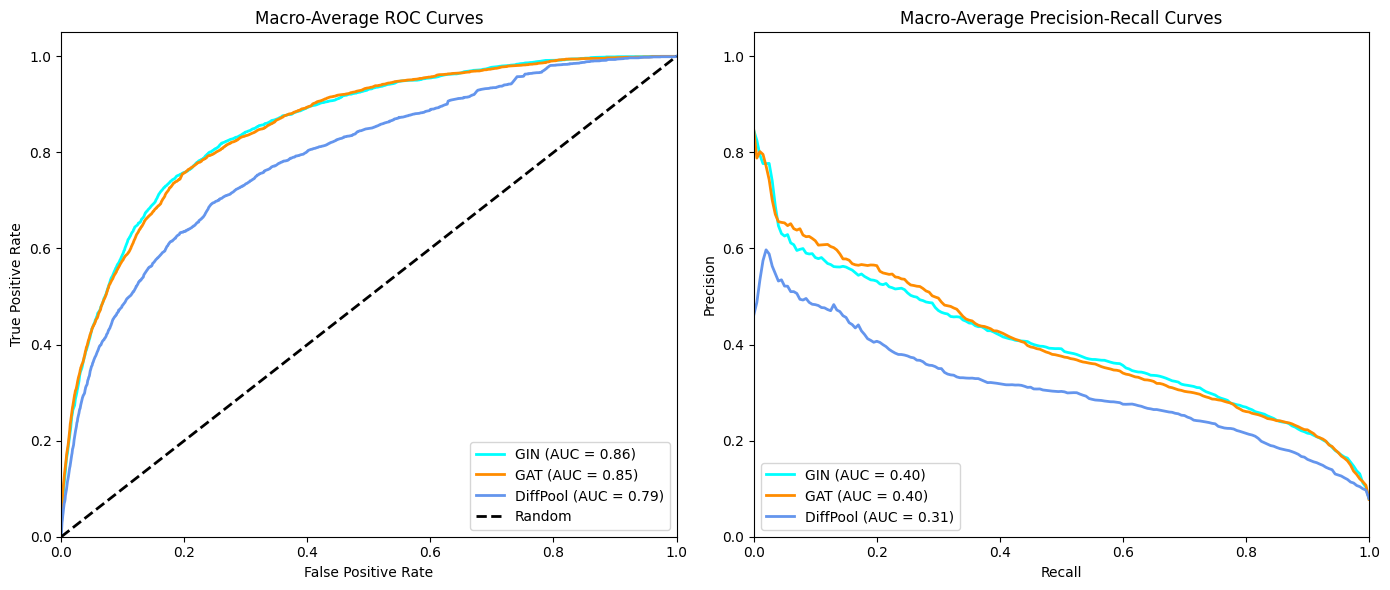


=== AUC Summary (Macro) ===


,AUC-ROC (Macro),AUC-PR (Macro)
Model,,
GIN,0.8565,0.3996
GAT,0.8544,0.4024
DiffPool,0.7898,0.3087



=== Misclassification Ratios Between Models ===


,Misclassification Ratio
Models,
GIN vs GAT,0.3085
GIN vs DiffPool,0.4312
GAT vs DiffPool,0.4912


In [28]:
# ---------- Helper Functions ---------- #
# Assuming num_classes and class_names are defined in a previously executed cell.
def plot_roc_pr_curves_multi(model_results, num_classes, class_names):
    """
    Plot per-model macro-average ROC and PR curves using standard matplotlib.
    model_results: dict -> { 'ModelName': (logits, labels) }
    num_classes: int, number of classes
    class_names: list of str, names of classes
    """
    plt.figure(figsize=(14, 6))
    lw = 2
    colors = itertools.cycle(['aqua', 'darkorange', 'cornflowerblue', 'red', 'green', 'purple', 'brown', 'pink', 'gray', 'olive', 'cyan', 'magenta', 'yellow'])

    # --- ROC Curves (Macro Average) ---
    plt.subplot(1, 2, 1)
    for model_name, (logits, labels) in model_results.items():
        probs = torch.softmax(logits, dim=1).detach().cpu().numpy()
        labels_np = labels.cpu().numpy()
        y_true_bin = label_binarize(labels_np, classes=np.arange(num_classes))

        # Calculate ROC curve for each class
        fpr = dict()
        tpr = dict()
        roc_auc = dict()
        for i in range(num_classes):
            fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], probs[:, i])
            roc_auc[i] = auc(fpr[i], tpr[i])

        # Aggregate all false positive rates
        all_fpr = np.unique(np.concatenate([fpr[i] for i in range(num_classes)]))

        # Interpolate all ROC curves at this points
        mean_tpr = np.zeros_like(all_fpr)
        for i in range(num_classes):
            mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])

        # Average and compute AUC
        mean_tpr /= num_classes
        macro_fpr = all_fpr
        macro_tpr = mean_tpr
        macro_roc_auc = auc(macro_fpr, macro_tpr)

        plt.plot(macro_fpr, macro_tpr, color=next(colors), lw=lw,
                 label=f'{model_name} (AUC = {macro_roc_auc:.2f})')


    plt.plot([0, 1], [0, 1], 'k--', lw=lw, label='Random')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Macro-Average ROC Curves')
    plt.legend(loc="lower right")

    # --- PR Curves (Macro Average) ---
    plt.subplot(1, 2, 2)
    colors = itertools.cycle(['aqua', 'darkorange', 'cornflowerblue', 'red', 'green', 'purple', 'brown', 'pink', 'gray', 'olive', 'cyan', 'magenta', 'yellow']) # Reset colors

    for model_name, (logits, labels) in model_results.items():
        probs = torch.softmax(logits, dim=1).detach().cpu().numpy()
        labels_np = labels.cpu().numpy()
        y_true_bin = label_binarize(labels_np, classes=np.arange(num_classes))

        # Calculate PR curve for each class
        precision = dict()
        recall = dict()
        average_precision = dict()
        for i in range(num_classes):
            precision[i], recall[i], _ = precision_recall_curve(y_true_bin[:, i], probs[:, i])
            average_precision[i] = average_precision_score(y_true_bin[:, i], probs[:, i])

        # A "macro-average" precision-recall score is the unweighted mean of the per-class
        # average precision scores. Plotting a macro PR curve is less standard than macro ROC.
        # A common way is to average precision at each recall threshold.
        # Let's calculate mean precision at interpolated recall levels.

        # Aggregate all recall points
        all_recall = np.unique(np.concatenate([recall[i] for i in range(num_classes)]))

        # Interpolate all PR curves at this points
        mean_precision = np.zeros_like(all_recall)
        for i in range(num_classes):
            # Need to sort recall in increasing order for interp
            sorted_recall_indices = np.argsort(recall[i])
            mean_precision += np.interp(all_recall, recall[i][sorted_recall_indices], precision[i][sorted_recall_indices])

        # Average and compute AUC
        mean_precision /= num_classes
        macro_recall = all_recall
        macro_precision = mean_precision
        # Note: AUC for the interpolated macro PR curve is not the same as average_precision_score(macro)
        # Use the average_precision_score(macro) calculated in evaluate_metrics_collect for the score
        macro_pr_auc_score = average_precision_score(y_true_bin, probs, average='macro')


        plt.plot(macro_recall, macro_precision, color=next(colors), lw=lw,
                 label=f'{model_name} (AUC = {macro_pr_auc_score:.2f})') # Use macro score here


    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Macro-Average Precision-Recall Curves')
    plt.legend(loc="lower left")

    plt.tight_layout()
    plt.show()


def compute_auc_scores_multi(model_results, num_classes):
    """
    Compute macro AUC-ROC and AUC-PR scores for each model in multi-class.
    """
    auc_scores = {}
    for model_name, (logits, labels) in model_results.items():
        probs = torch.softmax(logits, dim=1).detach().cpu().numpy()
        labels_np = labels.cpu().numpy()
        n_classes = probs.shape[1]
        y_true_bin = label_binarize(labels_np, classes=np.arange(n_classes))

        try:
            # Use score functions that support multi-class averaging
            roc_auc = roc_auc_score(y_true_bin, probs, average='macro')
        except ValueError:
            # This can happen if a class is missing in y_true or y_score
            roc_auc = float('nan') # or handle specifically if needed

        try:
            # Use score functions that support multi-class averaging
            pr_auc = average_precision_score(y_true_bin, probs, average='macro')
        except ValueError:
            # This can happen if a class is missing in y_true or y_score
            pr_auc = float('nan') # or handle specifically if needed


        auc_scores[model_name] = {
            "AUC-ROC (Macro)": roc_auc,
            "AUC-PR (Macro)": pr_auc
        }
    return auc_scores


def compute_misclassification_ratios(model_results):
    """
    Compute pairwise misclassification ratios between models.
    Shows how often models disagree on predictions.
    """
    predictions = {}
    for model_name, (logits, _) in model_results.items():
        predictions[model_name] = torch.argmax(logits, dim=1).cpu().numpy()

    model_names = list(predictions.keys())
    ratios = {}
    for m1, m2 in itertools.combinations(model_names, 2):
        diff = np.mean(predictions[m1] != predictions[m2])
        ratios[f"{m1} vs {m2}"] = diff
    return ratios


# ---------- Run Evaluation ---------- #
# Assuming model_results, num_classes, and class_names are defined from previous cells.

model_results = {
    'GIN': (logits_gin, labels_gin),
    'GAT': (logits_gat, labels_gat),
    'DiffPool': (logits_dp, labels_dp)
}

# Plot multi-class AUC-ROC and AUC-PR curves (Macro Average)
# Ensure num_classes and class_names are available
if 'num_classes' in globals() and 'class_names' in globals():
     plot_roc_pr_curves_multi(model_results, num_classes, class_names)
else:
     print("num_classes or class_names not defined. Skipping plotting.")

# Compute macro AUC and Misclassification
if 'num_classes' in globals():
     auc_scores = compute_auc_scores_multi(model_results, num_classes)
     misclass_ratios = compute_misclassification_ratios(model_results)

     # ---------- Combine Results into Table ---------- #
     summary_data = []
     for model_name, metrics in auc_scores.items():
          # Ensure metrics are floats and not numpy.float64 for display
          summary_data.append({
              'Model': model_name,
              'AUC-ROC (Macro)': float(metrics.get('AUC-ROC (Macro)', float('nan'))),
              'AUC-PR (Macro)': float(metrics.get('AUC-PR (Macro)', float('nan')))
          })


     # Misclassification ratios in readable format
     misclass_rows = [{'Models': key, 'Misclassification Ratio': float(value)} for key, value in misclass_ratios.items()]
     auc_df = pd.DataFrame(summary_data).set_index('Model')
     mis_df = pd.DataFrame(misclass_rows).set_index('Models')

     # Display summary tables
     print("\n=== AUC Summary (Macro) ===")
     display(auc_df.round(4))

     print("\n=== Misclassification Ratios Between Models ===")
     display(mis_df.round(4))
else:
     print("num_classes not defined. Skipping AUC summary and misclassification ratios.")